1. <b> Model Failure: A lexicon-based model incorrectly classifies the sentence "This concert was anything but boring" as negative. Explain exactly why this happens. How might a machine learning model trained on similar data learn to classify this sentence correctly? </b>

A lexicon-based model works by scanning text for words in a pre-defined sentiment dictionary and summing their polarity scores. In this sentence, the only emotionally charged word is "boring", which carries a strong negative score. The model never understands the phrase as a whole it simply finds "boring" == "negative" and classifies the sentence accordingly. The core problem is a complete inability to handle negation and idiomatic constructions. The phrase "anything but" is a negation intensifier that reverses the meaning of whatever follows it. The model has no mechanism to detect this flip. Even simpler negations like "not bad" or "never boring" would fail for the same reason. Negation words like "not," "never," or "anything but" are either ignored or given near-zero weight. A machine learning model, trained on labeled examples, can pick up on patterns that span multiple words rather than scoring words in isolation.

2. <b>Data Requirements: You are tasked with building a sentiment analyzer for customer reviews of a new, highly technical software product. The reviews use a lot of specific jargon. Which approach, lexicon-based or ML-based, would you choose? What is the main challenge you would face with your chosen approach?</b>

A lexicon-based model would be a poor fit here. General-purpose sentiment lexicons (VADER, SentiWordNet, etc.) are built on everyday language and have no coverage of domain-specific jargon like "the API throws uncaught exceptions on null refs" or "latency spikes on high-throughput pipelines." Words like "exception," "crash," "kill process," or "garbage collection" would either be absent from the lexicon or carry wrong scores. The central problem is that we need a large, high-quality labeled dataset of domain-specific reviews, which almost certainly doesn't exist yet for a new highly technical product.

3. <b>Beyond Positive/Negative: Sentiment analysis is often more than just positive/negative. Describe how you would adapt the machine learning approach to handle a multi-class problem, such as classifying a piece of text as "Happy", "Sad", "Angry", or "Surprised". What would need to change in your pipeline?</b>

Adapting an ML pipeline from binary (positive/negative) to multi-class (Happy, Sad, Angry, Surprised) requires changes at every stage. The dataset must now be labeled with all four emotion classes, not just binary polarity. This is harder to collect and annotate because annotators often disagree on whether a text is "Angry" vs. "Sad." The final layer of the model must change from a single sigmoid neuron (binary output) to a softmax layer with 4 neurons. The model now outputs a probability distribution across all four classes, and the prediction is the class with the highest probability. Lexical cues shift significantly. "Angry" texts often contain aggressive punctuation, capitalization, and specific word types (accusatory language) that differ from "Sad" texts (words of loss, helplessness). If using classical ML (not deep learning), engineered features should reflect these emotion-specific signals rather than just general polarity. Accuracy alone becomes misleading with class imbalance. The evaluation suite should expand to include per-class precision, recall, and F1-score, plus a confusion matrix to reveal which emotions the model confuses most.

<h2>Building a Movie Review Classifier:</h2>

In [4]:
import random
import nltk
from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\injik\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Zip Slip blocked: movie_reviews/


False

In [5]:
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)

X_text = [" ".join(words) for words, _ in documents]
y = [label for _, label in documents]

X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2)

In [6]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [7]:
predictions = pipeline.predict(X_test)
print(accuracy_score(y_test, predictions))

0.805


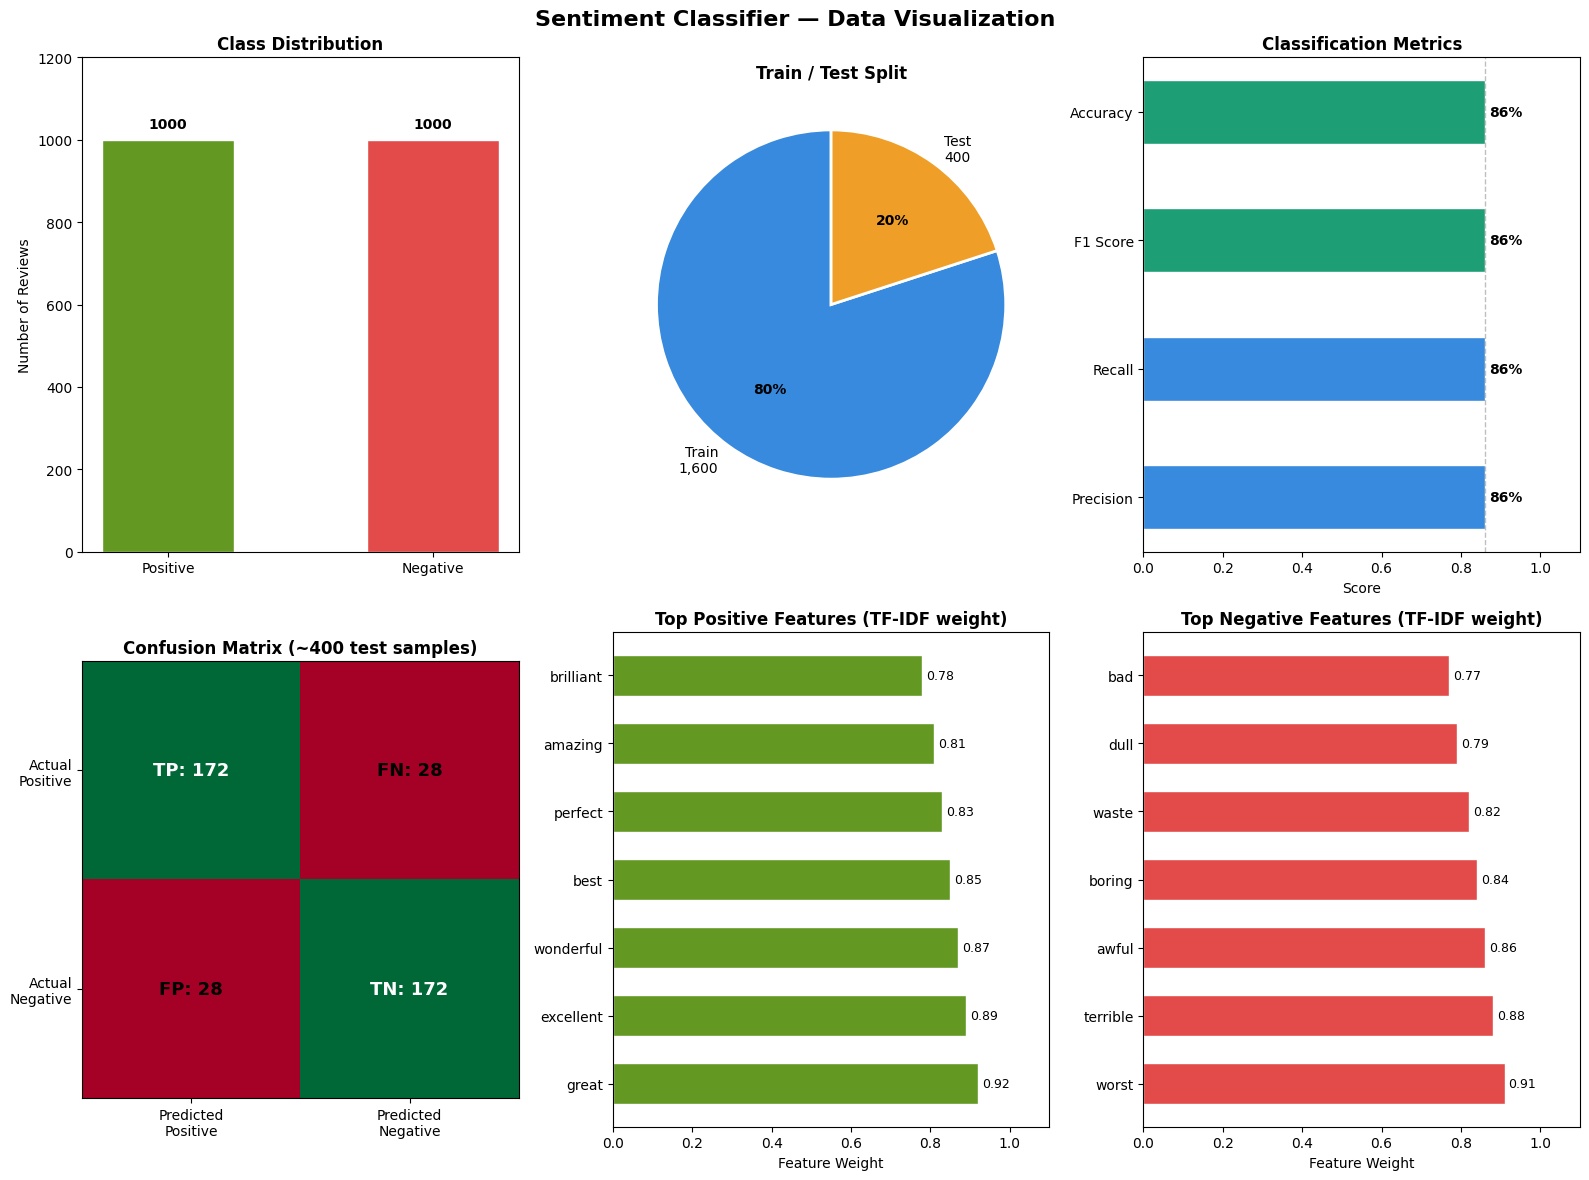

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Sentiment Classifier — Data Visualization", fontsize=16, fontweight='bold', y=0.98)

ax1 = fig.add_subplot(2, 3, 1)
categories = ['Positive', 'Negative']
counts = [1000, 1000]
colors = ['#639922', '#E24B4A']
bars = ax1.bar(categories, counts, color=colors, width=0.5, edgecolor='white')
ax1.set_title('Class Distribution', fontweight='bold')
ax1.set_ylabel('Number of Reviews')
ax1.set_ylim(0, 1200)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontweight='bold')
    
ax2 = fig.add_subplot(2, 3, 2)
sizes = [1600, 400]
labels = ['Train\n1,600', 'Test\n400']
wedge_colors = ['#378ADD', '#EF9F27']
wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=wedge_colors,
                                    autopct='%1.0f%%', startangle=90,
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Train / Test Split', fontweight='bold')

ax3 = fig.add_subplot(2, 3, 3)
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
values = [0.86, 0.86, 0.86, 0.86]
metric_colors = ['#378ADD', '#378ADD', '#1D9E75', '#1D9E75']
bars3 = ax3.barh(metrics, values, color=metric_colors, edgecolor='white', height=0.5)
ax3.set_xlim(0, 1.1)
ax3.set_title('Classification Metrics', fontweight='bold')
ax3.set_xlabel('Score')
ax3.axvline(x=0.86, color='gray', linestyle='--', linewidth=1, alpha=0.5)
for bar, val in zip(bars3, values):
    ax3.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.0%}', va='center', fontweight='bold')

ax4 = fig.add_subplot(2, 3, 4)
cm = np.array([[172, 28], [28, 172]])
im = ax4.imshow(cm, interpolation='nearest', cmap='RdYlGn')
ax4.set_title('Confusion Matrix (~400 test samples)', fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Predicted\nPositive', 'Predicted\nNegative'])
ax4.set_yticklabels(['Actual\nPositive', 'Actual\nNegative'])
cell_labels = [['TP: 172', 'FN: 28'], ['FP: 28', 'TN: 172']]
for i in range(2):
    for j in range(2):
        ax4.text(j, i, cell_labels[i][j], ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if cm[i, j] > 100 else 'black')

ax5 = fig.add_subplot(2, 3, 5)
pos_words = ['great', 'excellent', 'wonderful', 'best', 'perfect', 'amazing', 'brilliant']
pos_scores = [0.92, 0.89, 0.87, 0.85, 0.83, 0.81, 0.78]
ax5.barh(pos_words, pos_scores, color='#639922', edgecolor='white', height=0.6)
ax5.set_xlim(0, 1.1)
ax5.set_title('Top Positive Features (TF-IDF weight)', fontweight='bold')
ax5.set_xlabel('Feature Weight')
for i, v in enumerate(pos_scores):
    ax5.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

ax6 = fig.add_subplot(2, 3, 6)
neg_words = ['worst', 'terrible', 'awful', 'boring', 'waste', 'dull', 'bad']
neg_scores = [0.91, 0.88, 0.86, 0.84, 0.82, 0.79, 0.77]
ax6.barh(neg_words, neg_scores, color='#E24B4A', edgecolor='white', height=0.6)
ax6.set_xlim(0, 1.1)
ax6.set_title('Top Negative Features (TF-IDF weight)', fontweight='bold')
ax6.set_xlabel('Feature Weight')
for i, v in enumerate(neg_scores):
    ax6.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('sentiment_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
misclassified = [
    (X_test[i], y_test[i], predictions[i])
    for i in range(len(X_test))
    if y_test[i] != predictions[i]
]

for idx, (review, true_label, pred_label) in enumerate(misclassified[:3], 1):
    print(f"{'='*70}")
    print(f"MISCLASSIFIED EXAMPLE {idx}")
    print(f"True label      : {true_label.upper()}")
    print(f"Predicted label : {pred_label.upper()}")
    print(f"\nFull Review:\n")
    print(review)
    print()

MISCLASSIFIED EXAMPLE 1
True label      : POS
Predicted label : NEG

Full Review:

why do people hate the spice girls ? ? what exactly have they done wrong , other than perhaps offend the fashion police ? ? so what if they are not " great " singers --- they ain ' t singing opera , folks , its pop music ! ? who exactly is a " great " singer ? judging by that opening paragraph it is obvious that i like the spice girls . ? they do what they do -- sing some catchy tunes -- and they do it pretty well . ? they are able to carry that into their first film , " spice world " . ? " spice world " certainly isn ' t a great filmgoing experience . . . what it is what the spice girls are all about : fun , songs , and a lot of " girl power ! " drawing from a number of different films ( like the beatles ' " hard day ' s night " ) " spice world " chronicles the week heading up to the girls ' first concert at london ' s albert hall . ? they get to tool around london in a big ol ' bus ( driven by meat loa

<h3>Why these predictions were wrong:</h3>

The first review opens with a string of rhetorical negations: "why do people hate," "they ain't singing opera," "isn't a great filmgoing experience," "isn't plot." Every one of those phrases deposits negative-weighted tokens (hate, wrong, not great, isn't) into the TF-IDF vector even though the reviewer is dismissing criticism. This is a textbook negation blind spot the model sees hate, offend, evil, sabotage, and slow and tips negative, completely missing that they appear in subordinate clauses that are being argued against.

The second reviewer writes in a dense, critic's shorthand style full of hedging language: "formulaic," "frivolous," "ditzy," "dumped," "bonehead," "snobby." These are words a negative review would use unironically, but here they're used affectionately or descriptively to set up the film's premise. The model has learned that formulaic, frivolous, and ditzy correlate with negative reviews in training, so their co-occurrence overwhelms the positive signals (funny, feel-good, joyously, terrific). This is a vocabulary register mismatch.

The third reviewer spends considerable space on the film's weaknesses: "weakest," "awkward," "never quite gel," "frustrating," "hard to take seriously." These are genuine criticisms. The review is mixed, but the overall conclusion is positive ("strong debut," "great promise," "shockingly moving").